In [83]:
import scipy.io
import networkx as nx 
import bct 
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import nilearn
from nilearn import datasets, plotting, surface

# Preparation of dataset for use
num_subjects = 9

# definition of directory with dataset
dir_fmri_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_desikan/'
dir_fmri_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_destrieux/'

dir_eeg_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_desikan/'
dir_eeg_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_destrieux/'

# importing labels of atlas
mat_desikan = scipy.io.loadmat('/strombolihome/fribeiro/Dataset/source_reconstructed_FC/label_dsk.mat', squeeze_me=True)
labels_desikan = mat_desikan['label_dsk']
labels_desikan[67] = 'rINS' # small correction

mat_destrieux = scipy.io.loadmat('/strombolihome/fribeiro/Dataset/source_reconstructed_FC/label_dstrx.mat', squeeze_me=True)
labels_destrieux = mat_destrieux['label_dstrx']
labels_destrieux = labels_destrieux[12:160]
labels_destrieux[147] = 'rS_temporal_transverse' # small correction

In [94]:
# Script for creating graphs from fMRI and EEG connectivity data (coverting MATLAB matrices)

#1.Creation of average Graph 
def createAvGraph(file,data_type):
    
    # Load Matlab file with connectivity matrix for each time point - 3D matrix
    mat = scipy.io.loadmat(file)

    if data_type == 'fmri':
        conn_matrix = mat['connFMRI'].transpose() #connectivity fMRI matrix with numpy format
    elif data_type == 'eeg': #for now only for broad band TODO others !
        conn_matrix = mat['connEEGbroad'].transpose() #connectivity EEG matrix with numpy format
    elif data_type == 'eeg_alpha':
        conn_matrix = mat['connEEGalpha'].transpose()
    elif data_type == 'eeg_beta':
        conn_matrix = mat['connEEGbeta'].transpose()
    elif data_type == 'eeg_delta':
        conn_matrix = mat['connEEGdelta'].transpose()
    elif data_type == 'eeg_gamma':
        conn_matrix = mat['connEEGgamma'].transpose()
    elif data_type == 'eeg_theta':
        conn_matrix = mat['connEEGtheta'].transpose()
        
    t_points = conn_matrix.shape[0] # number of layers of multilayer matrix
    num_areas = conn_matrix.shape[1] #number of nodes of the graph
    
    # Get average connectivity matrix
    av_conn = np.zeros((num_areas,num_areas))
       
    for i in range(t_points):
        
        av_conn = av_conn + conn_matrix[i]
            
    av_conn = av_conn/t_points 
    
    G = nx.from_numpy_matrix(av_conn)
    
    return G

#2. Creation of array of graphs (equivalent to layers)
def createArrayGraph(file,data_type):
    
    # Load Matlab file with connectivity matrix for each time point - 3D matrix
    mat = scipy.io.loadmat(file)
    
    if data_type == 'fmri':
        conn_matrix = mat['connFMRI'].transpose() #connectivity fMRI matrix with numpy format
    elif data_type == 'eeg': #for now only for broad band TODO others !
        conn_matrix = mat['connEEGbroad'].transpose() #connectivity EEG matrix with numpy format
    elif data_type == 'eeg_alpha':
        conn_matrix = mat['connEEGalpha'].transpose()
    elif data_type == 'eeg_beta':
        conn_matrix = mat['connEEGbeta'].transpose()
    elif data_type == 'eeg_delta':
        conn_matrix = mat['connEEGdelta'].transpose()
    elif data_type == 'eeg_gamma':
        conn_matrix = mat['connEEGgamma'].transpose()
    elif data_type == 'eeg_theta':
        conn_matrix = mat['connEEGtheta'].transpose()

    t_points = conn_matrix.shape[0] # number of layers of multilayer matrix
    num_areas = conn_matrix.shape[1] #number of nodes of the graph
    
    array_graphs = np.empty(t_points, dtype=object) 
    
    for i in range(t_points):
        array_graphs[i] = nx.from_numpy_matrix(conn_matrix[i])
        
    return array_graphs

#concatenating all subjects
def createArrayGraphAllSubjects(file,type_data):
    
    array_graphs_all = []
    
    for f in range(0,len(file)):
        array_graphs = createArrayGraph(file[f], type_data)
        if f == 0:
            array_graphs_all = array_graphs
        else:
            array_graphs_all = np.concatenate([array_graphs_all, array_graphs])
    
    return array_graphs_all

#3. Threshold graph with given proportion
def thresholdGraph(G, threshold, type_data, type_threshold):
    
    if(type_data == 'fmri'):
        # get absolute value connectivity matrix
        conn_matrix = abs(nx.to_numpy_array(G))
    else:
        conn_matrix = nx.to_numpy_array(G)
     
    if (type_threshold == 'abs'):
        # to threshold graph keeping edges with weight equal or above certain value
        conn_new = bct.utils.threshold_absolute(conn_matrix, threshold, True)
    else:
        # to threshold graph keeping the top % of the edges 
        conn_new = bct.utils.threshold_proportional(conn_matrix, threshold, True)
        #add all weights equal to the minimal value kept
        min_val = np.min(conn_new[np.nonzero(conn_new)])
        index = np.transpose(np.where(conn_matrix == min_val))
        idx_i, idx_j = zip(*index)
        conn_new[idx_i, idx_j] = conn_matrix[idx_i, idx_j]
    
    #for the fMRI data we need to recover non-absolute values as Phase Coherence is between -1 and 1
    if(type_data == 'fmri'):
        
        ind_keep = np.transpose(np.nonzero(conn_new))
        conn_new = np.zeros((G.number_of_nodes(), G.number_of_nodes()))
        min_positive = 1 #to store minimum positive value kept of phase coherence
        max_negative = -1 #to store maximum negative value kept of phase coherence
        
        idx_i, idx_j = zip(*ind_keep)

        conn_new[idx_i, idx_j] = nx.to_numpy_array(G)[idx_i, idx_j]
        
        # remove self loops
        np.fill_diagonal(conn_new, 0)
        
        #In case we want the minimum value of connectivity kept
        
        #for ind in ind_keep:
        #    #print(nx.to_numpy_array(G)[ind[0],ind[1]])
        #    conn_new[ind[0],ind[1]] = nx.to_numpy_array(G)[ind[0],ind[1]]
        #    #print(conn_new[ind[0],ind[1]])
        #    if nx.to_numpy_array(G)[ind[0],ind[1]] > 0 and nx.to_numpy_array(G)[ind[0],ind[1]] < min_positive:
        #        min_positive = nx.to_numpy_array(G)[ind[0],ind[1]]
        #    elif nx.to_numpy_array(G)[ind[0],ind[1]] < 0 and nx.to_numpy_array(G)[ind[0],ind[1]] > max_negative:
        #        max_negative = nx.to_numpy_array(G)[ind[0],ind[1]]
        
        G_new = nx.from_numpy_matrix(conn_new)
        
        return [G_new, conn_new, min_positive, max_negative]
    
    else:
        min_coh = np.amin(conn_new) #to store minimum value kept of imaginary part of coherency
        G_new = nx.from_numpy_matrix(conn_new)
        
        return [G_new, conn_new, min_coh]  

#4. Get the components of the graph after thresholding
def getThresholdComponents(G,threshold,data, type_threshold):
    
    if data == 'fmri':
        G_new, conn_matrix, min_pos, max_neg = thresholdGraph(G, threshold, data, type_threshold)
    else:
        G_new, conn_matrix, min_coh = thresholdGraph(G, threshold, data, type_threshold)
    
    graph_components = sorted(nx.connected_components(G_new), key=len, reverse=True)
    
    return graph_components


In [95]:
from community import community_louvain
#import community as community_louvain
import sys
sys.path.append('python-modularity-maximization')


def findCommunitiesLouvain(file):

    G = nx.from_numpy_matrix(file)
    #first compute the best partition
    part = community_louvain.best_partition(G) #returns dictionary assign a community (integer) to each node
    mod = community_louvain.modularity(part, G) #compute modularity
    print("Modularity of the network:", mod)
    #print(part)

    values = [part.get(node) for node in G.nodes()]

    number_communities = max(values)+1
    print("Number of communities:", number_communities)
    count_communities = np.zeros((number_communities,), dtype=int)
    content_communities = []
    for n in range(number_communities):
        content_communities.append([])
    for key,value in part.items():
        count_communities[value] += 1
        content_communities[value].append(key)
    
    print(count_communities)
    #print(content_communities)
    
    return content_communities

In [86]:
file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj01/NMI_components_1_threshold11.0_fmri_dsk.npy')
communities_fmri = findCommunitiesLouvain(file)
print(communities_fmri[1])

Modularity of the network: 0.2815359107352505
Number of communities: 2
[264 136]
[6, 11, 13, 15, 16, 17, 18, 19, 31, 33, 37, 39, 41, 42, 43, 45, 46, 49, 50, 51, 54, 56, 58, 59, 60, 62, 63, 64, 65, 66, 69, 70, 71, 73, 75, 76, 79, 81, 83, 84, 87, 89, 90, 91, 94, 98, 111, 112, 115, 116, 120, 121, 122, 123, 128, 141, 144, 146, 148, 149, 151, 157, 158, 164, 165, 166, 167, 170, 172, 173, 177, 180, 181, 183, 184, 186, 190, 197, 198, 211, 213, 214, 215, 217, 220, 222, 231, 232, 239, 243, 244, 249, 252, 253, 254, 257, 262, 263, 265, 266, 267, 268, 269, 270, 287, 288, 290, 292, 293, 303, 308, 310, 318, 320, 343, 347, 348, 351, 353, 358, 359, 361, 364, 365, 366, 369, 370, 371, 373, 381, 382, 383, 386, 388, 389, 398]


In [96]:
file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj01/NMI_components_1_threshold7.000000000000001_eeg_alpha_dsk.npy')
communities_eeg_alpha = findCommunitiesLouvain(file)
print(communities_eeg_alpha)


Modularity of the network: 0.11481241302896063
Number of communities: 8
[47 36 51 94 49 73 48  2]
[[0, 8, 33, 35, 39, 41, 56, 61, 64, 67, 93, 100, 125, 150, 158, 160, 166, 169, 194, 195, 199, 205, 209, 213, 218, 225, 229, 241, 261, 267, 276, 280, 284, 285, 290, 294, 308, 319, 320, 322, 329, 338, 351, 353, 354, 376, 394], [1, 2, 3, 6, 16, 17, 24, 50, 51, 77, 80, 88, 95, 103, 104, 119, 127, 142, 148, 164, 214, 223, 230, 247, 257, 265, 268, 293, 298, 304, 310, 316, 317, 331, 364, 393], [4, 10, 21, 22, 23, 42, 43, 45, 49, 54, 58, 66, 68, 89, 96, 102, 111, 113, 116, 129, 133, 135, 141, 153, 174, 200, 207, 211, 219, 220, 236, 239, 248, 262, 272, 275, 281, 283, 299, 325, 327, 341, 348, 350, 370, 371, 382, 387, 389, 392, 397], [5, 7, 9, 11, 12, 18, 19, 29, 30, 31, 36, 37, 52, 74, 78, 85, 90, 97, 108, 109, 117, 123, 126, 134, 139, 140, 146, 161, 162, 168, 172, 173, 176, 179, 183, 184, 185, 186, 190, 197, 210, 212, 215, 216, 221, 222, 224, 226, 228, 231, 232, 233, 234, 238, 245, 246, 249, 255, 2

In [118]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy

#to create linkage tree and plot the dendogram
def plot_dendogram(model, **kwargs):
    
    counts = np.zeros(model.children_.shape[0])
    num_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < num_samples:
                current_count += 1 #leaf node
            else:
                current_count += counts[child_idx - num_samples]
        counts[i] = current_count
    
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    
    hierarchy.dendrogram(linkage_matrix, **kwargs)

def findCommunitiesHierarchicalSingleLinkage(file):
    
    model = AgglomerativeClustering(linkage="single", distance_threshold=0, n_clusters=None).fit(file)
    plot_dendogram(model, truncate_mode='level', p=3)
    plt.show()
    #clustering = AgglomerativeClustering(linkage="single", affinity='precomputed').fit_predict(file)
    clustering = AgglomerativeClustering(linkage="single", distance_threshold = 2, n_clusters = None).fit_predict(file)

    return clustering

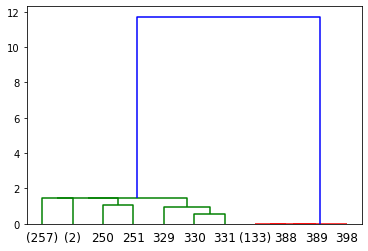

[0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 1 0 1 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1
 0 1 1 0 0 1 0 1 0 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0
 1 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 1 1
 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 1 0
 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0
 0 0 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 1 1 1 0 0 1
 1 1 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0]


In [106]:
file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj01/NMI_components_1_threshold11.0_fmri_dsk.npy')

clustering_fmri = findCommunitiesHierarchicalSingleLinkage(file)

print(clustering_fmri)

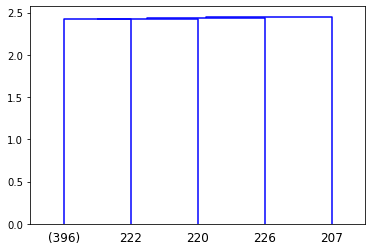

[179 163 257  29 162 211  29   1   7 239  28 156 267 247 241  13   3 165
   1 152 159 175   5 160   0 134  11 204 193 221 149 191   6 166  12 143
 251 230 207 238   1 176   1 216   1 147 137 117 258 167 183  14   4 184
 215  39 213  61 177 249 150  62  10  57 225 263 219  62 169 265 229 212
  82  31  26   0 139  58 194  16   3 168 261 226 146 148 245 144   3 181
 217 260  59   0 136 209   1   1  58 164 157 240  19   3   3 208 180  13
   1   1   6  17   1 243 262 170 206   1 244   3  61  27   6 189 250 266
 253   1   1 256   1 255 185 103 259 161 142 187 223 127  28  73  29   0
 118  59 199  39  64  61 197  31 140 202 224  23  20 231 264  12  62 158
   1 114 141  30 131  27 254 222 186   1   1   1 205  14 268 248 153  81
   8 188  78 201 234   1  56   6  29 117 105  59  16  30 133 198 233 171
  57  80 214  27 112 182  40  62  29 132 246 145 120 173 203  79 102   1
 196 252 195 200  87  61 151  29 155  92 121 192  89  62 218  72  69   2
  90  77   1   0 124 130 122  61  74  97 154 107  7

In [119]:
file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj01/NMI_components_1_threshold7.000000000000001_eeg_alpha_dsk.npy')

clustering_eeg_alpha = findCommunitiesHierarchicalSingleLinkage(file)

print(clustering_eeg_alpha)

In [91]:
intersection_fmri = np.intersect1d(np.nonzeros(clustering_fmri), communities_fmri[1])
print(intersection_fmri)

intersection_eeg_alpha = np.intersect1d(clustering_eeg_alpha, communities_eeg_alpha[1])
print(intersection_eeg_alpha)

[  6  11  13  15  16  17  18  19  31  33  37  39  41  42  43  45  46  49
  50  51  54  56  58  59  60  62  63  64  65  66  69  70  71  73  75  76
  79  81  83  84  87  89  90  91  94  98 111 112 115 116 120 121 122 123
 128 141 144 146 148 149 151 157 158 164 165 166 167 170 172 173 177 180
 181 183 184 186 190 197 198 211 213 214 215 217 220 222 231 232 239 243
 244 249 252 253 254 257 262 263 265 266 267 268 269 270 287 288 290 292
 293 303 308 310 318 320 343 347 348 351 353 358 359 361 364 365 366 369
 370 371 373 381 382 383 386 388 389 398]
[]


In [92]:
# to check the number of components for the these time points - only 1 component (fully connected)

def comparisonNumberComponents(file, time_points, type_data, atlas, threshold):
    
    G_array = createArrayGraph(file, type_data)
    num_components = np.zeros(len(time_points))
    
    n=0
    for t in time_points:
        #print(t)
            
        graph_components = getThresholdComponents(G_array[t],threshold,type_data, 'percentage')
        num_components[n] = len(graph_components) #save number of components for each time point
        n += 1
        
    print(num_components)

comparisonNumberComponents(dir_fmri_desikan + 'subj01-7T/conn_desi_phase_coh_time_fmri.mat', intersection_fmri, 'fmri', 'dsk', 0.11)
comparisonNumberComponents(dir_eeg_desikan + 'subj01-7T/conn_desi_cohi_time_eeg_alpha_correct_subj1-7T_.mat', intersection_eeg_alpha, 'eeg_alpha', 'dsk', 0.07)

threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.         -0.98976446
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
  -0.99964343]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.         -0.98976446  0.         ...  0.          0.
   0.        ]
 [ 0.          0.         -0.99964343 ...  0.          0.
   0.        ]]
threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
  -0.99436368]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.         -0.99436368 ...  0.          0.
   0.        ]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 

threshold
[[ 0.         -0.99169997  0.         ...  0.          0.
   0.        ]
 [-0.99169997  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99883016  0.
   0.        ]
 ...
 [ 0.          0.         -0.99883016 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.         -0.99436252  0.         ...  0.          0.
   0.        ]
 [-0.99436252  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99747735  0.
   0.        ]
 ...
 [ 0.          0.         -0.99747735 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.         -0.9942911   0.         ...  0.          0.
   0.        ]
 [-0.9942

threshold
[[ 0.         -0.99797111  0.         ...  0.         -0.98867211
  -0.99747051]
 [-0.99797111  0.          0.         ...  0.          0.99622228
   0.9999724 ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.98867211  0.99622228  0.         ...  0.          0.
   0.99684   ]
 [-0.99747051  0.9999724   0.         ...  0.          0.99684
   0.        ]]
threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.         -0.99835191
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.99980811]
 [ 0.          0.         -0.99835191 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.99980811  0.
   0.        ]]
threshold
[[ 0.          0.          0.         ... -0.9884686 

threshold
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.99206404]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.99206404 0.         ... 0.         0.         0.        ]]
threshold
[[0.         0.99840255 0.         ... 0.         0.         0.        ]
 [0.99840255 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]


threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.99690458 0.99690053]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.99690458 0.         ... 0.         0.         1.        ]
 [0.         0.99690053 0.         ... 0.         1.         0.        ]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.98884803 0.99981753]
 [0.         0.         0.         ... 0.98431445 0.         0.        ]
 ...
 [0.         0.         0.98431445 ... 0.         0.         0.        ]
 [0.         0.98884803 0.         ... 0.         0.         0.98582272]
 [0.         0.99981753 0.         ... 0.         0.98582272 0.        ]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.     

threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99132896  0.
   0.        ]
 ...
 [ 0.          0.         -0.99132896 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99966007 -0.99828117
   0.        ]
 ...
 [ 0.          0.         -0.99966007 ...  0.          0.99641385
   0.        ]
 [ 0.          0.         -0.99828117 ...  0.99641385  0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.         -0.99057083  0.         ...  0.          0.
   0.   

[]


In [102]:
# to compare communities for time points with similar set of components - fully connected graph but completely different communities

from community import community_louvain
from igraph import *

def communityFindingLouvain(G, atlas):
    
    if atlas == 'dsk':
        num_regions = 68
    else:
        num_regions = 148
    
    part = community_louvain.best_partition(G) #returns dictionary assign a community (integer) to each node
    mod = community_louvain.modularity(part, G) #compute modularity
    #print("Modularity: ", mod)
        
    #creates a list with the community number for each node in the order that appears in G.nodes()
    communities = [part.get(node) for node in G.nodes()] 
        
    #determine number of nodes in each community
    num_communities = max(communities)+1
    count_communities = np.zeros((num_communities,), dtype=int)
    content_communities = np.zeros(num_regions)
    for key,value in part.items():
        count_communities[value] += 1
        content_communities[key] = int(value) #store for node (key) the community label (value)
    
    return  mod, num_communities, content_communities  

def comparisonCommunities(file, time_points, type_data, atlas, threshold):
    
    G_array = createArrayGraph(file, type_data)
    num_time_points = len(time_points)
    
    num_communities = np.zeros(num_time_points)
    
    nmi = np.zeros((num_time_points, num_time_points)) #comparison between all time points component distribution
    np.fill_diagonal(nmi, 1) #fill the diagonal as NMI will be 1
    
    communities = np.empty(num_time_points, dtype=object)
    
    n=0
    for t in time_points:
        
        if type_data == 'fmri':
            G, conn_matrix, min_pos, max_neg = thresholdGraph(G_array[t], threshold, type_data, 'percentage')
        else:
            G, conn_matrix, min_coh = thresholdGraph(G_array[t], threshold, type_data, 'percentage')
            
        giant_component = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        conn_matrix = nx.to_numpy_matrix(giant_component)
        #conversion to binary undirected graph
        conn_matrix = bct.utils.binarize(conn_matrix)
        # Best partition according to Louvain algorithm for original network
        G = nx.from_numpy_matrix(conn_matrix)
        
        modularity, num_communities[n], communities[n] = communityFindingLouvain(G, 'dsk')
        n += 1
    
    #print(communities)
    
    #compute nmi between each time point communities
    for n in range(num_time_points):
        for m in range(1,num_time_points):
            
            nmi[n,m] = compare_communities(communities[n], communities[m], method='nmi')
            nmi[m,n] = nmi[n,m] #matrix is symmetrical
    
    np.fill_diagonal(nmi, 0) #fill the diagonal as NMI will be 1
    print(nmi)
    
    f = plt.figure(figsize=(20, 20))
    plt.matshow(nmi, fignum=f.number)
    plt.xticks(fontsize=14, rotation=45)
    plt.yticks(fontsize=14)
    cb = plt.colorbar()
    cb.ax.tick_params(labelsize=14)
    
    plt.show()



[[0.         0.14016278 0.10104887 ... 0.13378739 0.10732124 0.08500785]
 [0.14016278 0.         0.3405305  ... 0.11916899 0.1136568  0.14182867]
 [0.10104887 0.3405305  0.         ... 0.16940064 0.12467952 0.12746405]
 ...
 [0.13378739 0.11916899 0.16940064 ... 0.         0.47901759 0.08585079]
 [0.10732124 0.1136568  0.12467952 ... 0.47901759 0.         0.10325911]
 [0.08500785 0.14182867 0.12746405 ... 0.08585079 0.10325911 0.        ]]


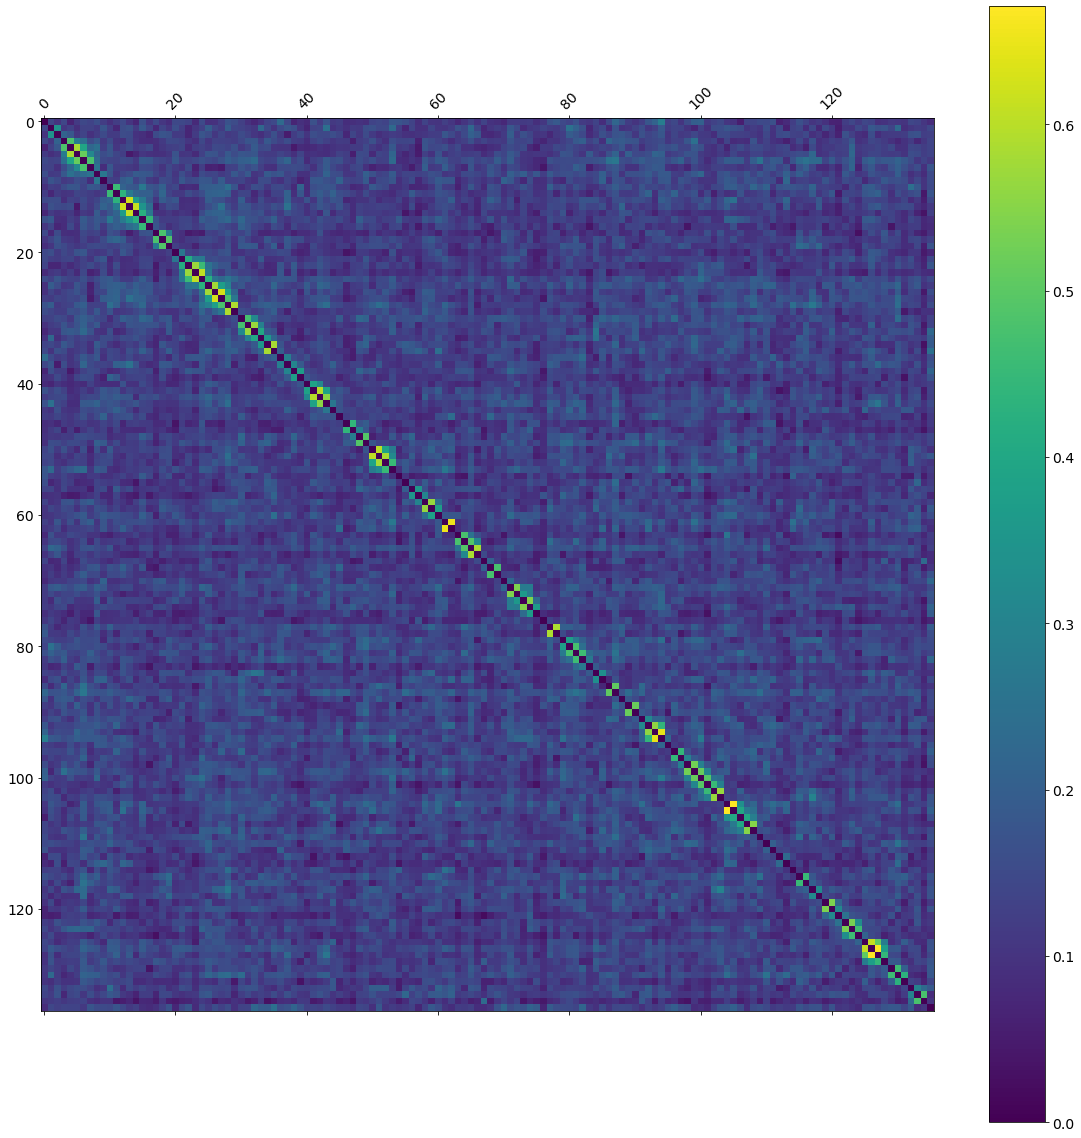

In [103]:
comparisonCommunities(dir_fmri_desikan + 'subj01-7T/conn_desi_phase_coh_time_fmri.mat', intersection_fmri, 'fmri', 'dsk', 0.11)
#comparisonCommunities(dir_eeg_desikan + 'subj01-7T/conn_desi_cohi_time_eeg_alpha_correct_subj1-7T_.mat', intersection_eeg_alpha, 'eeg_alpha', 'dsk', 0.07)

[[0.         0.24776585 0.1786127  ... 0.10358317 0.07575212 0.23821689]
 [0.24776585 0.         0.1387479  ... 0.12439452 0.15656266 0.12333486]
 [0.1786127  0.1387479  0.         ... 0.21063743 0.10847812 0.15095999]
 ...
 [0.10358317 0.12439452 0.21063743 ... 0.         0.08300467 0.11880713]
 [0.07575212 0.15656266 0.10847812 ... 0.08300467 0.         0.09951195]
 [0.23821689 0.12333486 0.15095999 ... 0.11880713 0.09951195 0.        ]]


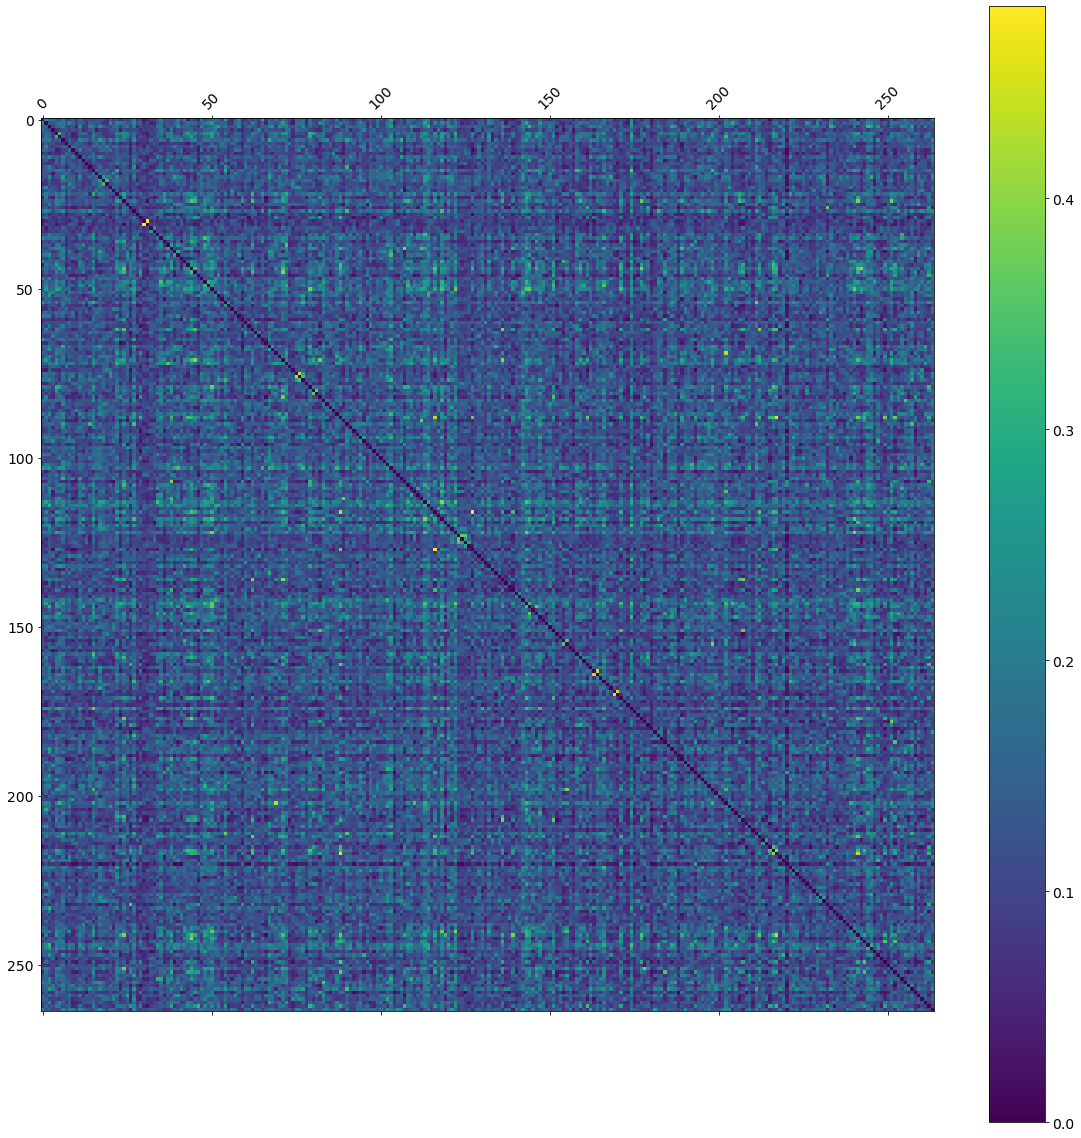

In [104]:
comparisonCommunities(dir_fmri_desikan + 'subj01-7T/conn_desi_phase_coh_time_fmri.mat', communities_fmri[0], 'fmri', 'dsk', 0.11)
